# Imports

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

from dotenv import load_dotenv

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.options.display.float_format = "{:,.4f}".format

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=3)

USE_ONLINE_DATA = True
load_dotenv()

print(f"Analysis window: {START_DATE.date()} to {END_DATE.date()}")
fred = Fred(os.getenv("FRED_API_KEY"))

Analysis window: 2023-06-01 to 2026-06-01


In [2]:
FRED_SERIES = {
    "DGS2": "2Y Treasury yield",
    "DGS5": "5Y Treasury yield",
    "DGS10": "10Y Treasury yield",
    "DGS30": "30Y Treasury yield",
    "BAMLC0A0CM": "ICE BofA US Corporate OAS",
    "BAMLH0A0HYM2": "ICE BofA US High Yield OAS",
    "VIXCLS": "CBOE VIX close",
    "T10YIE": "10Y breakeven inflation",
}

In [3]:
ETF_TICKERS = ["AGG", "LQD", "HYG", "TLT"]
PORTFOLIO_WEIGHTS = {"AGG": 0.40, "LQD": 0.25, "HYG": 0.20, "TLT": 0.15}

print(f"Total weights: {sum(PORTFOLIO_WEIGHTS.values())}")

Total weights: 1.0


# Utils

In [4]:
def fetch_fred_series(series_id, start=START_DATE, end=END_DATE):
    data_series = fred.get_series(series_id)

    df = pd.DataFrame(data_series)
    df.columns = [series_id]
    df = df.loc[(df.index >= pd.to_datetime(start)) & (df.index <= pd.to_datetime(end))]
    return df


def fetch_fed_panel(series_dict, start, end):
    frames = []

    for series_id in series_dict:
        frames.append(fetch_fred_series(series_id, start, end))

    panel = pd.concat(frames, axis=1).sort_index()

    panel.index = pd.to_datetime(panel.index).tz_localize(None)

    panel = panel.asfreq("B").ffill()
    panel = panel.dropna(how="all")

    return panel


def _ar1(n, sigma, phi, rng):
    eps = rng.normal(0, sigma, n)
    out = np.zeros(n)

    for i in range(1, n):
        out[i] = phi * out[i - 1] + eps[i]

    return out


def engineer_factor_changes(levels):

    levels = levels.copy().sort_index()
    out = pd.DataFrame(index=levels.index)

    for col in ["DGS2", "DGS5", "DGS10", "DGS30"]:
        if col in levels.columns:
            out[f"d_{col}_bp"] = levels[col].diff() * 100

    required_yields = ["DGS2", "DGS5", "DGS10", "DGS30"]

    if all(c in levels.columns for c in required_yields):
        levels["Rate_Level"] = levels[required_yields].mean(axis=1)
        levels["Slope_10Y_2Y"] = levels["DGS10"] - levels["DGS2"]
        levels["Curvature_5Y"] = 2 * levels["DGS5"] - levels["DGS2"] - levels["DGS10"]
        out["d_Rate_Level_bp"] = levels["Rate_Level"].diff() * 100
        out["d_10y2y_Slope_bp"] = levels["Slope_10Y_2Y"].diff() * 100
        out["d_Curvature_bp"] = levels["Curvature_5Y"].diff() * 100

    for col in ["BAMLC0A0CM", "BAMLH0A0HYM2"]:
        if col in levels.columns:
            out[f"d_{col}_bp"] = levels[col].diff() * 100

    if "VIXCLS" in levels.columns:
        out["d_VIX_points"] = levels["VIXCLS"].diff()

    if "T10YIE" in levels.columns:
        out["d_T10YIE_bp"] = levels["T10YIE"].diff() * 100

    return out.dropna(how="all")


def download_etf_prices(tickers, start, end):

    raw = yf.download(
        tickers,
        start=start.strftime("%Y-%m-%d"),
        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        threads=True,
    )

    if "Close" in raw.columns.get_level_values(0):
        prices = raw["Close"].copy()
    elif "Adj Close" in raw.columns.get_level_values(0):
        prices = raw["Adj Close"].copy()

    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index().ffill().dropna(how="all")

    return prices


def portfolio_returns_from_prices(prices, weights):
    rets = prices.pct_change().dropna(how="all")
    available = [ticker for ticker in weights if ticker in rets.columns]

    w = pd.Series({ticker: weights[ticker] for ticker in available}, dtype=float)
    w = w / w.sum()

    port = rets[available].mul(w, axis=1).sum(axis=1).rename("Portfolio_Return")

    return port, rets[available]

# Loading Factors

In [5]:
market_levels = fetch_fed_panel(FRED_SERIES, START_DATE, END_DATE)
market_levels = market_levels.dropna(
    thresh=max(2, int(0.60 * len(market_levels))), axis=1
)

print(market_levels.shape)
display(market_levels.tail())

(782, 8)


,DGS2,DGS5,DGS10,DGS30,BAMLC0A0CM,BAMLH0A0HYM2,VIXCLS,T10YIE
2026-05-25,4.1300,4.2700,4.5600,5.0700,0.7400,2.7400,16.5900,2.4000
2026-05-26,4.0100,4.1900,4.5000,5.0300,0.7400,2.7200,17.0100,2.4000
2026-05-27,4.0000,4.1700,4.4800,5.0100,0.7400,2.7100,16.2900,2.3900
2026-05-28,3.9900,4.1500,4.4500,4.9800,0.7300,2.7200,15.7400,2.3900
2026-05-29,3.9900,4.1500,4.4500,4.9800,0.7300,2.7200,15.7400,2.3800


In [6]:
factor_changes = engineer_factor_changes(market_levels)
PCA_FACTOR_COLS = [
    "d_DGS2_bp",
    "d_DGS5_bp",
    "d_DGS10_bp",
    "d_DGS30_bp",
    "d_BAMLC0A0CM_bp",
    "d_BAMLH0A0HYM2_bp",
    "d_VIX_points",
    "d_T10YIE_bp",
]

REGRESSION_FACTOR_COLS = [
    "d_Rate_Level_bp",
    "d_10y2y_Slope_bp",
    "d_Curvature_bp",
    "d_BAMLC0A0CM_bp",
    "d_BAMLH0A0HYM2_bp",
    "d_VIX_points",
    "d_T10YIE_bp",
]

PCA_FACTOR_COLS = [
    c
    for c in PCA_FACTOR_COLS
    if c in factor_changes.columns and factor_changes[c].std() > 1e-12
]
REGRESSION_FACTOR_COLS = [
    c
    for c in REGRESSION_FACTOR_COLS
    if c in factor_changes.columns and factor_changes[c].std() > 1e-12
]

display(
    factor_changes[
        PCA_FACTOR_COLS
        + [c for c in REGRESSION_FACTOR_COLS if c not in PCA_FACTOR_COLS]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
d_DGS2_bp,781.0000,-0.0435,5.7758,-28.0000,-3.0000,0.0000,3.0000,23.0000
d_DGS5_bp,781.0000,0.0576,5.9894,-24.0000,-4.0000,0.0000,4.0000,24.0000
d_DGS10_bp,781.0000,0.1076,5.5198,-19.0000,-3.0000,0.0000,4.0000,19.0000
d_DGS30_bp,781.0000,0.1460,5.1413,-16.0000,-3.0000,0.0000,3.0000,17.0000
d_BAMLC0A0CM_bp,781.0000,-0.0883,1.3582,-5.0000,-1.0000,0.0000,1.0000,10.0000
d_BAMLH0A0HYM2_bp,781.0000,-0.2471,7.2311,-38.0000,-4.0000,0.0000,3.0000,59.0000
d_VIX_points,781.0000,0.0001,1.7968,-18.7100,-0.6200,-0.0700,0.5300,15.2900
d_T10YIE_bp,781.0000,0.0282,2.2813,-16.0000,-1.0000,0.0000,1.0000,13.0000
d_Rate_Level_bp,781.0000,0.0669,5.2540,-21.2500,-3.2500,0.0000,3.2500,20.0000
d_10y2y_Slope_bp,781.0000,0.1511,3.6191,-13.0000,-2.0000,0.0000,2.0000,14.0000


# Loading Portfolio Returns

In [7]:
etf_prices = download_etf_prices(ETF_TICKERS, START_DATE, END_DATE)
portfolio_returns, constituent_returns = portfolio_returns_from_prices(
    etf_prices, PORTFOLIO_WEIGHTS
)

print(portfolio_returns.dropna().shape[0])
display(portfolio_returns.tail().to_frame())

750


,Portfolio_Return
Date,
2026-05-22,0.0017
2026-05-26,0.0035
2026-05-27,0.0009
2026-05-28,0.0026
2026-05-29,0.0007


# Merge analysis dataset

In [8]:
model_data = factor_changes.join(portfolio_returns, how='inner')
model_data.tail()

,d_DGS2_bp,d_DGS5_bp,d_DGS10_bp,d_DGS30_bp,d_Rate_Level_bp,d_10y2y_Slope_bp,d_Curvature_bp,d_BAMLC0A0CM_bp,d_BAMLH0A0HYM2_bp,d_VIX_points,d_T10YIE_bp,Portfolio_Return
2026-05-22,5.0000,2.0000,-1.0000,-3.0000,0.7500,-6.0000,0.0000,-1.0000,-4.0000,-0.0600,1.0000,0.0017
2026-05-26,-12.0000,-8.0000,-6.0000,-4.0000,-7.5000,6.0000,2.0000,0.0000,-2.0000,0.4200,0.0000,0.0035
2026-05-27,-1.0000,-2.0000,-2.0000,-2.0000,-1.7500,-1.0000,-1.0000,0.0000,-1.0000,-0.7200,-1.0000,0.0009
2026-05-28,-1.0000,-2.0000,-3.0000,-3.0000,-2.2500,-2.0000,0.0000,-1.0000,1.0000,-0.5500,0.0000,0.0026
2026-05-29,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0.0007


# EDA

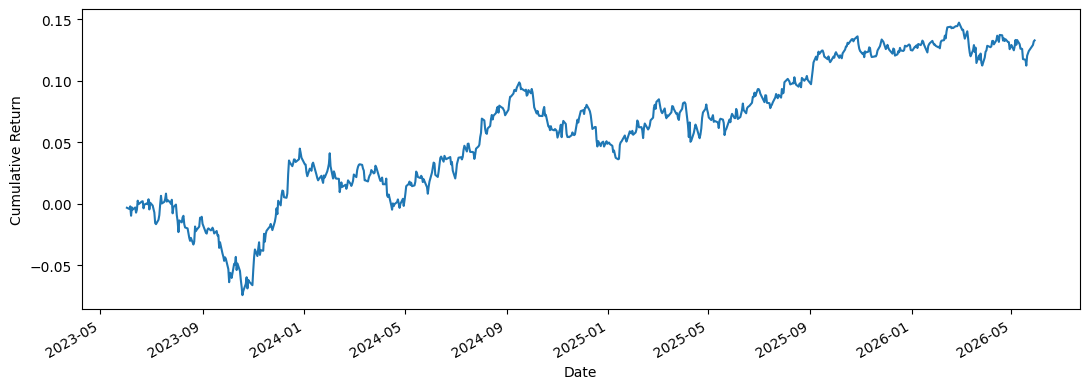

In [9]:
fig, ax = plt.subplots(figsize=(11,4))
portfolio_cum_return = (1 + model_data['Portfolio_Return']).cumprod() - 1
portfolio_cum_return.plot()
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

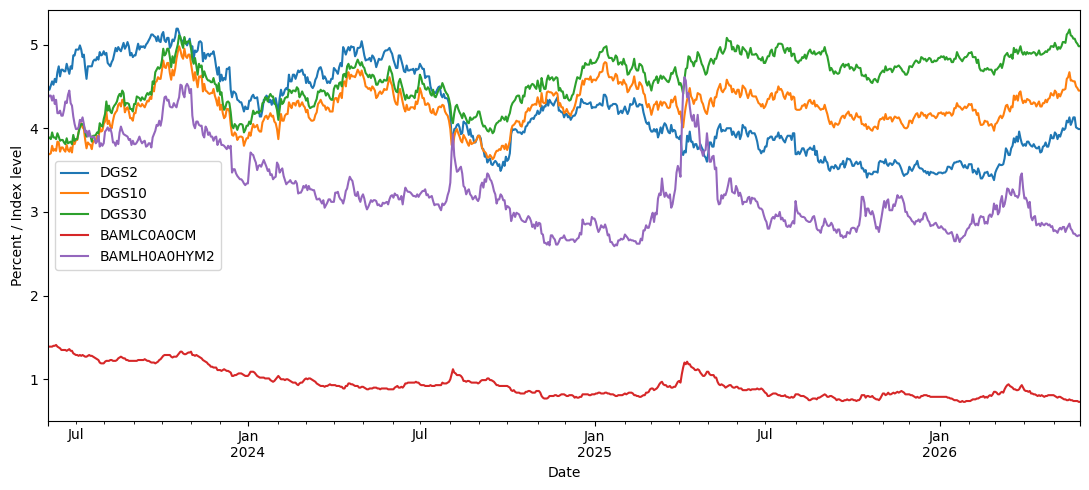

In [10]:
selected_level_cols = [c for c in ["DGS2","DGS10","DGS30","BAMLC0A0CM","BAMLH0A0HYM2"] if c in market_levels.columns]
fig, ax = plt.subplots(figsize=(11,5))
market_levels.loc[model_data.index.min():model_data.index.max(),selected_level_cols].plot(ax=ax)
ax.set_xlabel("Date")
ax.set_ylabel("Percent / Index level")
plt.tight_layout()
plt.show()

                   d_DGS2_bp  d_DGS5_bp  d_DGS10_bp  d_DGS30_bp  d_BAMLC0A0CM_bp  d_BAMLH0A0HYM2_bp  d_VIX_points  d_T10YIE_bp  \
d_DGS2_bp             1.0000     0.9156      0.7955      0.6123          -0.2831            -0.3757       -0.1189       0.4658   
d_DGS5_bp             0.9156     1.0000      0.9429      0.8035          -0.2737            -0.3125       -0.0636       0.5289   
d_DGS10_bp            0.7955     0.9429      1.0000      0.9382          -0.2335            -0.2209       -0.0157       0.5692   
d_DGS30_bp            0.6123     0.8035      0.9382      1.0000          -0.1797            -0.1148        0.0135       0.5098   
d_BAMLC0A0CM_bp      -0.2831    -0.2737     -0.2335     -0.1797           1.0000             0.7312        0.3842      -0.2743   
d_BAMLH0A0HYM2_bp    -0.3757    -0.3125     -0.2209     -0.1148           0.7312             1.0000        0.5478      -0.2781   
d_VIX_points         -0.1189    -0.0636     -0.0157      0.0135           0.3842          

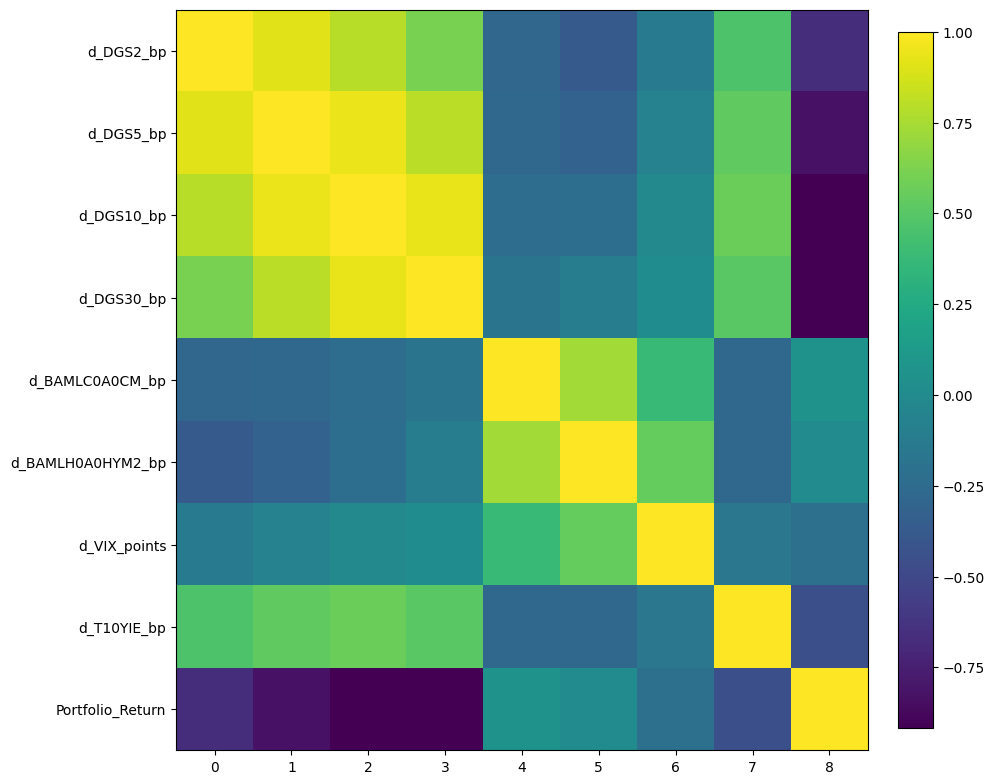

,d_DGS2_bp,d_DGS5_bp,d_DGS10_bp,d_DGS30_bp,d_BAMLC0A0CM_bp,d_BAMLH0A0HYM2_bp,d_VIX_points,d_T10YIE_bp,Portfolio_Return
d_DGS2_bp,1.0000,0.9160,0.7960,0.6120,-0.2830,-0.3760,-0.1190,0.4660,-0.6640
d_DGS5_bp,0.9160,1.0000,0.9430,0.8040,-0.2740,-0.3130,-0.0640,0.5290,-0.8260
d_DGS10_bp,0.7960,0.9430,1.0000,0.9380,-0.2330,-0.2210,-0.0160,0.5690,-0.9160
d_DGS30_bp,0.6120,0.8040,0.9380,1.0000,-0.1800,-0.1150,0.0130,0.5100,-0.9170
d_BAMLC0A0CM_bp,-0.2830,-0.2740,-0.2330,-0.1800,1.0000,0.7310,0.3840,-0.2740,0.0570
d_BAMLH0A0HYM2_bp,-0.3760,-0.3130,-0.2210,-0.1150,0.7310,1.0000,0.5480,-0.2780,0.0060
d_VIX_points,-0.1190,-0.0640,-0.0160,0.0130,0.3840,0.5480,1.0000,-0.1540,-0.2130
d_T10YIE_bp,0.4660,0.5290,0.5690,0.5100,-0.2740,-0.2780,-0.1540,1.0000,-0.4510
Portfolio_Return,-0.6640,-0.8260,-0.9160,-0.9170,0.0570,0.0060,-0.2130,-0.4510,1.0000


In [11]:
corr_cols = [c for c in PCA_FACTOR_COLS if c in model_data.columns] + ['Portfolio_Return']
corr = model_data[corr_cols].corr()
print(corr)
fig,ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr.values, aspect='auto')
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction = 0.046, pad=0.04)
plt.tight_layout()
plt.show()
display(corr.round(3))

 # PCA

In [12]:
pca_input = model_data[PCA_FACTOR_COLS].dropna()
y_for_pca = model_data.loc[pca_input.index, "Portfolio_Return"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_input)

pca = PCA()
pc_scores_array = pca.fit_transform(X_scaled)

pc_names = [f'PC{i+1}' for i in range(len(PCA_FACTOR_COLS))]
explained = pd.Series(pca.explained_variance_ratio_,index=pc_names,name='Explained_Variance_Ratio')
cum_explained = explained.cumsum().rename("Cumulative_Explained_Variance")

loadings = pd.DataFrame(pca.components_.T, index=PCA_FACTOR_COLS,columns=pc_names)

pca_scores = pd.DataFrame(pc_scores_array, index = pca_input.index, columns = pc_names)

display(pd.concat([explained,cum_explained],axis=1).round(4))
display(loadings.round(3))

,Explained_Variance_Ratio,Cumulative_Explained_Variance
PC1,0.5234,0.5234
PC2,0.2375,0.7609
PC3,0.0800,0.8409
PC4,0.0746,0.9155
PC5,0.0516,0.9672
PC6,0.0259,0.9930
PC7,0.0056,0.9986
PC8,0.0014,1.0000


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
d_DGS2_bp,0.4260,0.0730,-0.2400,-0.2520,-0.5540,0.2790,-0.5480,0.0840
d_DGS5_bp,0.4600,0.1570,-0.1630,-0.1660,-0.1520,0.0870,0.6450,-0.5130
d_DGS10_bp,0.4550,0.2240,-0.0330,-0.0680,0.2260,-0.0860,0.2760,0.7760
d_DGS30_bp,0.4060,0.2600,0.0510,-0.0230,0.6170,-0.2250,-0.4540,-0.3560
d_BAMLC0A0CM_bp,-0.2310,0.5020,0.3290,-0.4740,-0.2990,-0.5210,-0.0020,-0.0070
d_BAMLH0A0HYM2_bp,-0.2430,0.5600,0.2050,-0.0750,0.1870,0.7380,0.0170,0.0040
d_VIX_points,-0.1110,0.5350,-0.4570,0.6450,-0.1890,-0.2020,-0.0250,-0.0100
d_T10YIE_bp,0.3310,0.0010,0.7440,0.5070,-0.2790,0.0240,-0.0120,-0.0310


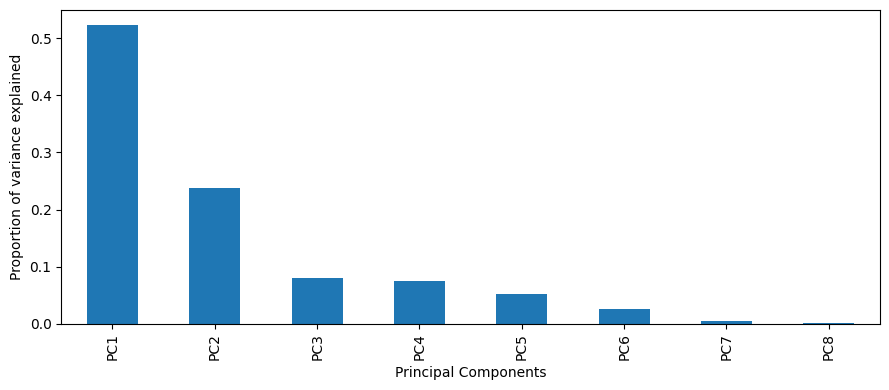

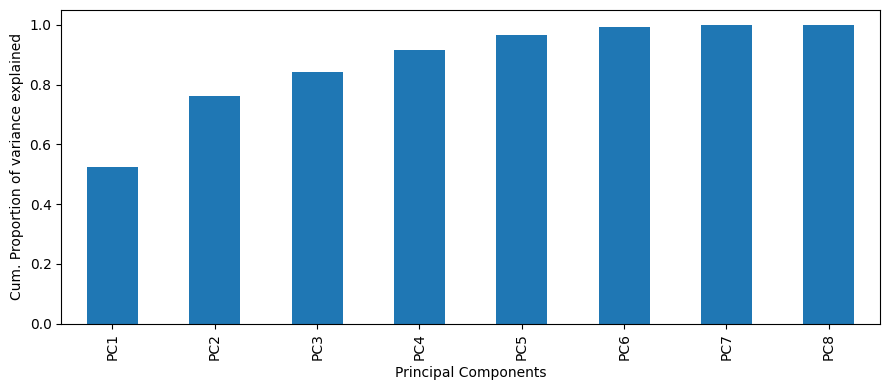

In [13]:
fig, ax = plt.subplots(figsize=(9,4))
explained.plot(kind='bar',ax=ax)
ax.set_xlabel("Principal Components")
ax.set_ylabel("Proportion of variance explained")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9,4))
cum_explained.plot(kind='bar',ax=ax)
ax.set_xlabel("Principal Components")
ax.set_ylabel("Cum. Proportion of variance explained")
plt.tight_layout()
plt.show()

# Regression Models

In [14]:
def fit_ols_model(y, X, hac_lags=5):
    X = X.copy()
    y = y.loc[X.index].copy()

    X_const = sm.add_constant(X, has_constant='add')
    model = sm.OLS(y, X_const).fit(cov_type='HAC',cov_kwds={'maxlags':hac_lags})

    table = pd.DataFrame(
        {
            'coef':model.params,
            'std_err':model.bse,
            't_stat':model.tvalues,
            'p_value':model.pvalues,
        }
    )
    metrics = {
        'R2' : model.rsquared,
        'Adj_R2' : model.rsquared_adj,
        'AIC':model.aic,
        'BIC' : model.bic,
        'N' : int(model.nobs), 
        'Method' : 'Statsmodels OLS with HAC robust std errors'
    }
    return model, table, metrics

raw_X_cols = [c for c in REGRESSION_FACTOR_COLS if c in model_data.columns and model_data[c].std() > 1e-12]
raw_X = model_data[raw_X_cols].dropna()
raw_y = model_data.loc[raw_X.index, "Portfolio_Return"]

raw_model, raw_coef_table, raw_metrics = fit_ols_model(raw_y, raw_X)
display(raw_metrics)
display(raw_coef_table.sort_values('p_value',na_position='last'))

{'R2': np.float64(0.9151998863946036),
 'Adj_R2': np.float64(0.9143998853228545),
 'AIC': np.float64(-7904.537185507845),
 'BIC': np.float64(-7867.576599855602),
 'N': 750,
 'Method': 'Statsmodels OLS with HAC robust std errors'}

,coef,std_err,t_stat,p_value
d_Rate_Level_bp,-0.0008,0.0000,-53.0060,0.0000
d_10y2y_Slope_bp,-0.0003,0.0000,-11.7072,0.0000
const,0.0002,0.0000,8.2038,0.0000
d_VIX_points,-0.0004,0.0001,-4.5831,0.0000
d_Curvature_bp,0.0001,0.0000,3.6428,0.0003
d_T10YIE_bp,0.0001,0.0000,2.5704,0.0102
d_BAMLH0A0HYM2_bp,-0.0000,0.0000,-1.7999,0.0719
d_BAMLC0A0CM_bp,-0.0002,0.0001,-1.5469,0.1219


In [15]:
threshold = 0.80
n_pcs = int(np.searchsorted(cum_explained.values,threshold)+1)
n_pcs = max(1, min(n_pcs, 5, pca_scores.shape[1]))

selected_pcs = pc_names[:n_pcs]
pc_X = pca_scores[selected_pcs].dropna()
pc_y = model_data.loc[pc_X.index, "Portfolio_Return"]

pc_model, pc_coef_table, pc_metrics = fit_ols_model(pc_y, pc_X)
display(pc_metrics)
display(pc_coef_table.sort_values('p_value',na_position='last'))

{'R2': np.float64(0.8724036725550723),
 'Adj_R2': np.float64(0.871890550594838),
 'AIC': np.float64(-7606.106155832582),
 'BIC': np.float64(-7587.62586300646),
 'N': 750,
 'Method': 'Statsmodels OLS with HAC robust std errors'}

,coef,std_err,t_stat,p_value
PC1,-0.0016,0.0000,-48.3798,0.0000
PC2,-0.0016,0.0001,-19.5068,0.0000
const,0.0002,0.0000,4.8882,0.0000
PC3,0.0004,0.0002,2.1597,0.0308


In [16]:
comparison = pd.DataFrame([raw_metrics,pc_metrics],index=['Raw model', 'PCA model'])
display(comparison)

,R2,Adj_R2,AIC,BIC,N,Method
Raw model,0.9152,0.9144,"-7,904.5372","-7,867.5766",750,Statsmodels OLS with HAC robust std errors
PCA model,0.8724,0.8719,"-7,606.1062","-7,587.6259",750,Statsmodels OLS with HAC robust std errors
